NAME: ALOK KUMAR MAVI

SECTION: B

ROLL.NO.: 05

CU ID: CU240251681

## LAB SHEET - 08

=== Decision Tree Performance Metrics ===
Accuracy : 0.6350
Precision: 0.6731
Recall   : 0.6422
F1-Score : 0.6573

=== Detailed Classification Report ===
              precision    recall  f1-score   support

Retained (0)       0.59      0.63      0.61        91
 Churned (1)       0.67      0.64      0.66       109

    accuracy                           0.64       200
   macro avg       0.63      0.63      0.63       200
weighted avg       0.64      0.64      0.64       200



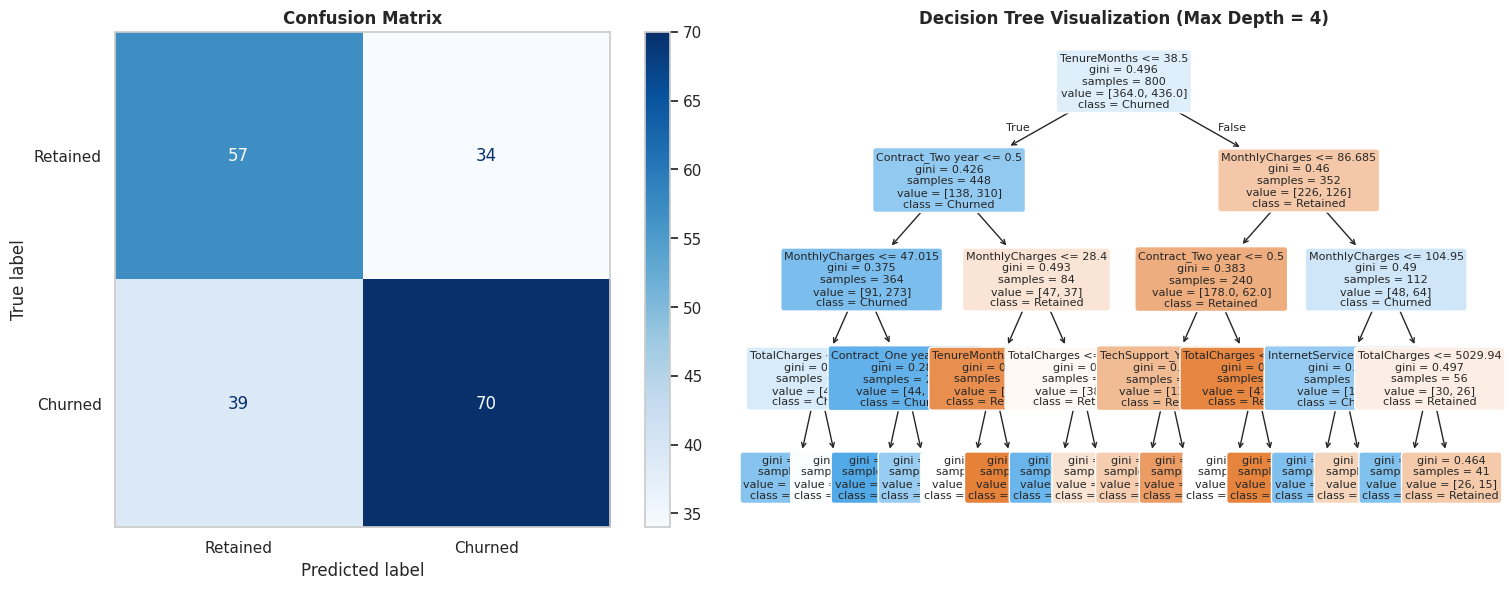

/tmp/ipykernel_671/2378669728.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


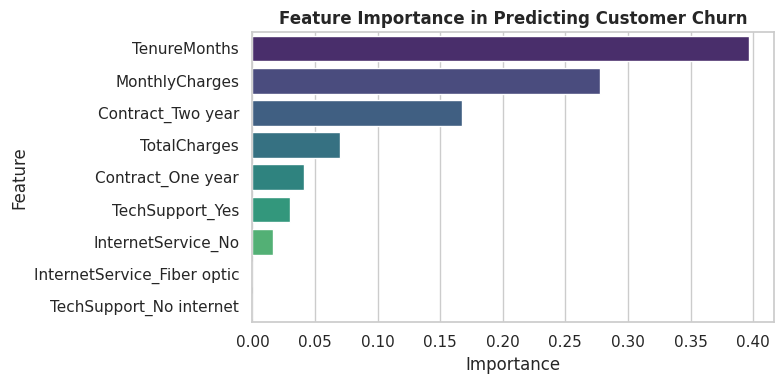

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

sns.set_theme(style="whitegrid")
np.random.seed(42)

# Step 1-3: Generate Synthetic Telco Churn Dataset & Preprocess
def generate_churn_dataset(record_count: int = 1000) -> pd.DataFrame:
    tenure_months = np.random.randint(1, 72, size=record_count)
    monthly_charges = np.random.uniform(18.0, 118.0, size=record_count)
    total_charges = tenure_months * monthly_charges + np.random.normal(0, 50, record_count)
    total_charges = np.clip(total_charges, 18.0, None)

    contract_types = np.random.choice(['Month-to-month', 'One year', 'Two year'], size=record_count, p=[0.55, 0.25, 0.20])
    internet_service = np.random.choice(['DSL', 'Fiber optic', 'No'], size=record_count, p=[0.35, 0.45, 0.20])
    tech_support = np.random.choice(['Yes', 'No', 'No internet'], size=record_count, p=[0.30, 0.50, 0.20])

    # Calculate churn probability based on domain rules
    churn_logit = (
        - 0.05 * tenure_months
        + 0.02 * monthly_charges
        + 1.2 * (contract_types == 'Month-to-month')
        - 0.8 * (contract_types == 'Two year')
        + 0.8 * (internet_service == 'Fiber optic')
        - 0.6 * (tech_support == 'Yes')
    )
    churn_probability = 1 / (1 + np.exp(-churn_logit))
    churn_target = (np.random.uniform(0, 1, record_count) < churn_probability).astype(int)

    return pd.DataFrame({
        'TenureMonths': tenure_months,
        'MonthlyCharges': np.round(monthly_charges, 2),
        'TotalCharges': np.round(total_charges, 2),
        'Contract': contract_types,
        'InternetService': internet_service,
        'TechSupport': tech_support,
        'Churn': churn_target
    })

churn_df = generate_churn_dataset(1000)

# One-Hot Encoding for categorical features
categorical_cols = ['Contract', 'InternetService', 'TechSupport']
encoded_df = pd.get_dummies(churn_df, columns=categorical_cols, drop_first=True)

feature_matrix = encoded_df.drop(columns=['Churn'])
target_vector = encoded_df['Churn']

# Step 4: Train-Test Split (80:20 Ratio)
X_train, X_test, y_train, y_test = train_test_split(
    feature_matrix, target_vector, test_size=0.20, random_state=42, stratify=target_vector
)

# Step 5: Model Training
churn_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    min_samples_split=10,
    random_state=42
)
churn_model.fit(X_train, y_train)

# Step 6: Model Predictions
y_pred = churn_model.predict(X_test)

# Step 7: Performance Evaluation
model_accuracy = accuracy_score(y_test, y_pred)
model_precision = precision_score(y_test, y_pred)
model_recall = recall_score(y_test, y_pred)
model_f1 = f1_score(y_test, y_pred)

print("=== Decision Tree Performance Metrics ===")
print(f"Accuracy : {model_accuracy:.4f}")
print(f"Precision: {model_precision:.4f}")
print(f"Recall   : {model_recall:.4f}")
print(f"F1-Score : {model_f1:.4f}\n")
print("=== Detailed Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Retained (0)', 'Churned (1)']))

# Step 8: Visualization - Confusion Matrix & Decision Tree
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_display = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Retained', 'Churned'], cmap='Blues', ax=axes[0]
)
axes[0].set_title("Confusion Matrix", fontsize=12, fontweight='bold')
axes[0].grid(False)

plot_tree(
    churn_model,
    feature_names=feature_matrix.columns,
    class_names=['Retained', 'Churned'],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=axes[1]
)
axes[1].set_title("Decision Tree Visualization (Max Depth = 4)", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Step 9: Feature Importance Analysis
importance_df = pd.DataFrame({
    'Feature': feature_matrix.columns,
    'Importance': churn_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title("Feature Importance in Predicting Customer Churn", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()



### Questions and Answers

**1. What is classification, and how does it differ from regression?**

* **Classification:** A supervised machine learning technique used to map input features to discrete, categorical class labels (e.g., predicting whether a customer will churn or stay).


* **Regression:** A supervised learning technique used to predict continuous numerical values (e.g., forecasting monthly bill amounts or house prices).



**2. Explain the working principle of the Decision Tree algorithm.**

* A Decision Tree uses a tree-like structure of decisions to recursively partition a dataset into smaller, more homogenous subsets based on feature values.


* Starting from the root node, it evaluates feature split conditions that maximize information gain or impurity reduction until reaching terminal leaf nodes that assign final class predictions.



**3. Differentiate between Gini Index and Entropy as splitting criteria.**

* **Gini Index:** Measures the probability of misclassifying a randomly chosen element if it were randomly labeled according to the distribution of labels in the node.

$$\text{Gini} = 1 - \sum_{i=1}^{C} p_i^2$$


* **Entropy:** Measures the degree of randomness or impurity in a node based on information theory concepts.

$$\text{Entropy} = -\sum_{i=1}^{C} p_i \log_2(p_i)$$


* **Difference:** Gini Index computes faster because it does not require logarithmic evaluations, whereas Entropy tends to generate slightly more balanced trees.

**4. What is a Confusion Matrix? Explain its components.**


A Confusion Matrix is a tabular layout used to evaluate the performance of a classification model by comparing actual target labels against predicted outcomes:

* **True Positives (TP):** Correctly predicted positive instances (e.g., churned customers correctly flagged as churned).
* **True Negatives (TN):** Correctly predicted negative instances (e.g., retained customers correctly flagged as retained).
* **False Positives (FP) / Type I Error:** Retained customers incorrectly predicted as churned.
* **False Negatives (FN) / Type II Error:** Churned customers incorrectly predicted as retained.

**5. Define Accuracy, Precision, Recall, and F1-Score. Why are these metrics important?**

* **Accuracy:** Overall proportion of correct predictions across all instances.

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$


* **Precision:** Ratio of true churn predictions to all positive predictions made by the model.

$$\text{Precision} = \frac{TP}{TP + FP}$$


* **Recall (Sensitivity):** Ratio of actual churn instances correctly identified by the model.

$$\text{Recall} = \frac{TP}{TP + FN}$$


* **F1-Score:** Harmonic mean of Precision and Recall, providing a balanced metric when dealing with class imbalance.

$$\text{F1-Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$



**6. What is overfitting in a Decision Tree? How can it be reduced?**

* **Overfitting:** Occurs when a Decision Tree grows unconstrained, memorizing training set noise and outliers rather than learning generalizable patterns, leading to high training accuracy but low test set performance.


* **Reduction Strategies:**
* Restricting maximum depth (`max_depth`).
* Setting minimum sample requirements for node splitting (`min_samples_split` or `min_samples_leaf`).
* Applying cost-complexity pruning (CCP).
* Using ensemble models like Random Forests or Gradient Boosted Trees.



**7. Why is customer churn prediction important for businesses?**

* **Cost Efficiency:** Acquiring new customers is significantly more expensive than retaining existing ones.
* **Revenue Protection:** Proactively identifying at-risk accounts allows organizations to deploy targeted retention offers, preserving recurring revenue streams.


* **Operational Feedback:** Pinpoints systemic product or service flaws driving customer dissatisfaction.



**8. What are the advantages and limitations of the Decision Tree algorithm?**

* **Advantages:** High interpretability (rule-based visualization), requires minimal data normalization, handles both continuous and categorical variables natively.


* **Limitations:** High variance (small changes in data alter tree structures drastically), susceptible to overfitting when deep, struggles with complex non-linear boundary interactions compared to ensemble methods.



**9. Mention three real-world applications of Decision Tree Classification other than customer churn prediction.**

* **Credit Risk Assessment:** Evaluating loan applications to classify applicants as high or low default risks.
* **Medical Diagnosis:** Classifying patient diagnostic metrics to identify early stages of diseases.


* **Fraud Detection:** Categorizing financial transactions as legitimate or fraudulent based on behavioral signatures.

**10. How can the insights obtained from a churn prediction model help organizations improve customer retention and business profitability?**

* **Targeted Marketing Campaigns:** Identifies specific high-risk segments (e.g., month-to-month fiber optic subscribers) to offer custom incentives.


* **Resource Optimization:** Directs customer success efforts toward high-value accounts with high churn probability rather than dispersing retention budgets uniformly.


* **Product Enhancements:** Highlights operational friction points—such as lack of tech support or high monthly charge tiers—enabling strategic product and pricing adjustments.